# **O Modelo BERT**
<font size=3>

Na aula anterior, construímos a fundação da NLP moderna ao implementar o *Transformer* completo para tarefas de tradução. Aqui, daremos um passo além, migrando do paradigma de geração de texto para o de **compreensão profunda de linguagem** (*Natural Language Understanding*). Estudaremos o modelo **BERT** (*Bidirectional Encoder Representations from Transformers*), dissecando matematicamente como sua natureza bidirecional permite capturar nuances semânticas e ambiguidades que modelos sequenciais ignoram.


## **1. Introdução:**
<font size=3>
    
A arquitetura *Transformer* completa (*Encoder-Decoder*) resolver problemas *seq2seq* como a **tradução**. Neste contexto, o objetivo é gerar uma sequência de saída palavra por palavra. Para isso, o *Decoder* precisava ser **autoregressivo**: ao gerar a palavra na posição $t$, ele só podia "olhar" para as palavras nas posições $1$ até $t-1$, o que chamamos de **_natural language generation_ (NLG)**.

<font size=3>

No entanto, a tradução é apenas uma das muitas facetas da NLP. Muitas vezes, não queremos gerar texto, mas sim **entender** profundamente o contexto. As principais aplicações desse paradigma  (**_natural language understanding_ (NLU)**) são:
 1. **Classificação de texto:** análise de sentimento, detecção de intenção, filtragem de *spam*, triagem jurídica;
 2. **Reconhecimento de entidades nomeadas:** o modelo identifica e extrai informações específicas dentro de um texto (_question answering_);
 3. **Similaridade semântica:** o NLU entende que palavras diferentes podem ter o mesmo significao (sinônimo e contexto).



### **1.1 O salto evolutivo:**
<font size=3>

Os modelos focados em geração (como a família GPT) utilizam a parte do **_Decoder_** do Transformer. Eles são excelentes em fluência, mas possuem uma "visão de túnel": leem estritamente da esquerda para a direita.

Para tarefas de compreensão NLU, essa restrição é prejudicial. Em 2018, o Google lançou o **BERT** (*Bidirectional Encoder Representations from Transformers*) [Devlin et al., 2018](https://arxiv.org/abs/1810.04805), que descartou o Decoder e focou exclusivamente na pilha de **_Encoders_**. Ao fazer isso, permitiu que o mecanismo de atenção olhasse para a frase inteira de uma só vez.

### **1.2 O problema do contexto:**
<font size=3>

Imagine que queremos criar um *embedding* para a palavra **"banco"** nas duas frases abaixo:
1. *"O homem foi ao **banco** depositar dinheiro."*
2. *"O homem foi ao **banco** da praça sentar."*

Em um modelo unidirecional (GPT ou RNN padrão), ao processar a palavra "banco", o modelo viu apenas: *"O homem foi ao..."*. Nesse ponto, é matematicamente impossível distinguir se o vetor resultante deve representar uma instituição financeira ou um assento. O contexto que resolve a ambiguidade ("depositar" ou "sentar") está no **futuro** (à direita).

O BERT resolve isso modelando a probabilidade baseada no contexto global. Enquanto modelos tradicionais maximizam $P(x_t \mid x_{<t})$, o BERT busca entender $x_t$ dado todo o resto:
$$
    P(x_t \mid x_1, \dots, x_{t-1}, x_{t+1}, \dots, x_T)
$$

>**Observação:** o termo "bidirecional" em BERT não se refere a uma abordagem semelhante a abordagem Bi-LSTM, onde a entrada sofre um *flip* para um segundo processamento de LSTM. Na verdade, o "bidirecional" está mais para um "omnidirecional", já que o BERT acessa todos os tokens de uma vez, graças ao mecanismo de Atenção.

### **1.3 Pré-treino vs. _fine-tuning_:**
<font size=3>

A revolução trazida pelo BERT também foi operacional, consolidando o paradigma de **_Transfer Learning_** em NLP:
1. **Pré-treino (_pre-training_):** O modelo é treinado em um *corpus* massivo (Wikipédia + Livros) para resolver tarefas genéricas, como preencher lacunas ("*Masked Language Modeling*"). Isso apresenta um custo computacional enorme. O resultado é um modelo que "conhece a linguagem".
   
2. **Ajuste fino (_fine-tuning_):** Pegamos esse modelo pré-treinado e adicionamos uma camada final para uma tarefa específica (ex: classificação de sentimentos). Isso é rápido e eficiente.


<font size=3><center>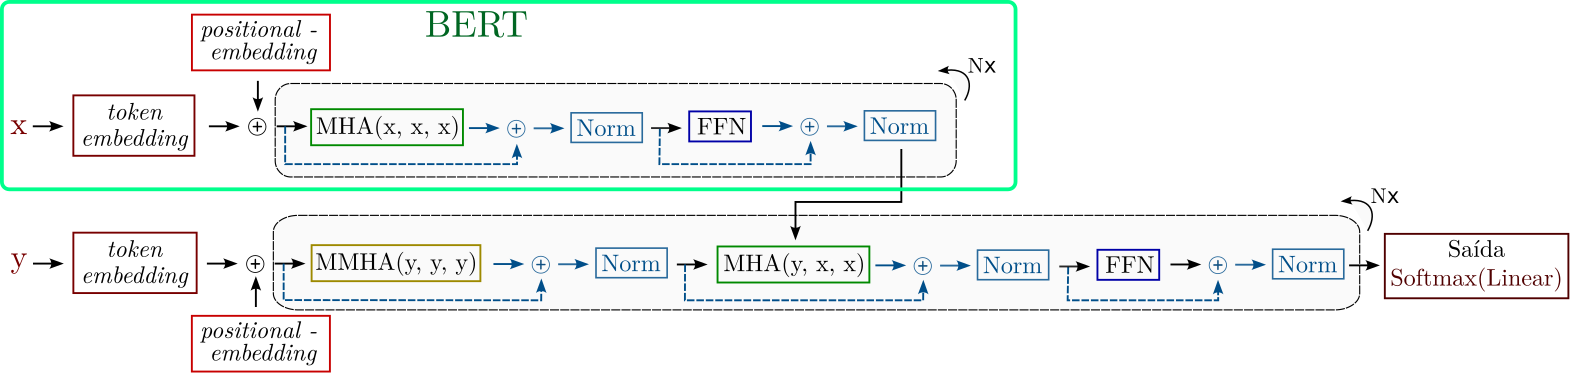</center></p><p style="text-align:center;"><em>BERT: Transformer encoder.</em>

## **2. A vetorização adaptada:**
<font size=3>

Na arquitetura Transformer, somamos apenas o *token embedding* com o *positional embedding*. O BERT introduz uma complexidade adicional para lidar com pares de frases. A representação vetorial final  de cada token é a soma *element-wise* de três vetores distintos:

<font size=3>
    
1. **_Token embedding_:** O vetor semântico da palavra.

2. **_Positional embedding_:** O vetor de posicionamento aprendido durante o treinamento.

3. **_Segment embedding_:** Um vetor que indica em qual **segmento de texto** um *token* pertence.

<font size=3><center>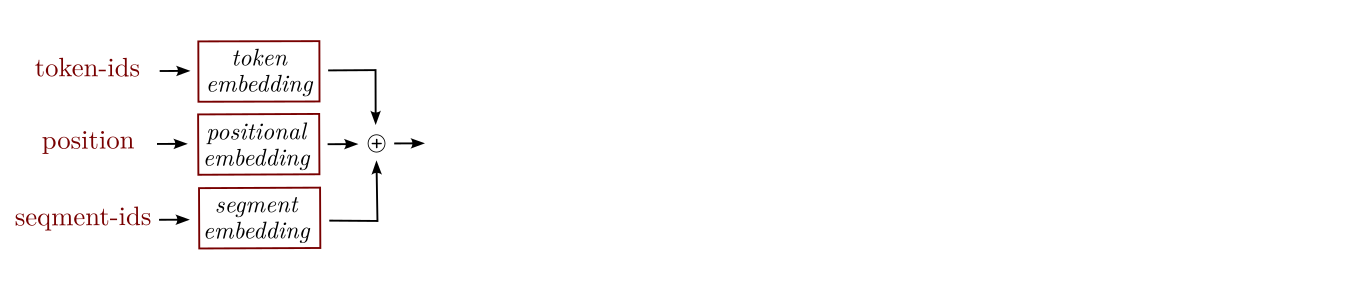</center></p><p style="text-align:center;"><em>A vetorização.</em>

### **2.1 _Segment embedding:_**
<font size=3>

O **_Segment Embedding_** cria uma distinção matemática no espaço vetorial. Ele afasta, geometricamente, as palavras da sentença **A** das palavras da sentença **B**, permitindo que o modelo trate as interações entre elas de forma distinta. Por exemplo, considere dois tipos de segmentos (pergunta e resposta):
- **Pergunta:** "Quem cantou?"
- **Resposta:** "A banda Queen tocou ontem."

A tokenização desse texto nos daria as seguintes listas:

<font size=2>

```python
tokens = ["[CLS]", "Quem", "canta", "[SEP]", "A", "banda", "Queen", "tocou", "[SEP]"]
# onde [CLS] vem de "classification", mas este token realiza o resumo matemático de todo o texto;
# já o token [SEP] é o separador das sentenças.

token_ids = [101, 2000, 3050, 102, 100, 4000, 5000, 6000, 102]

# Segment IDs (token type IDs):
# 0 = Sentença A (Pergunta)
# 1 = Sentença B (resposta)
segment_ids = [0, 0, 0, 0, 1, 1, 1, 1, 1]
# Note que o primeiro [SEP] ainda conta como parte da sentença A (0),
# e o segundo [SEP] fecha a sentença B (1).

```
<br>


#### **2.1.1 Operação matricial:**
<font size=3>

Nesta vetorização, a matriz de pesos é definida considerando a dimensão do *embedding* ($d_m \equiv \texttt{d-model} = \texttt{embed-dim}$) e o número de segmentações ($d_s \equiv \texttt{seg-dim}$), $W_{seg} \in \Re^{d_s,\, d_m}$. A lista `segment_ids` é, então, expandida em uma **matriz _one-hot_**, $I \in \Re^{L,\, d_s}$:
$$
I =
\begin{bmatrix}
0 & 1 \\
0 & 1 \\
0 & 1 \\
0 & 1 \\
1 & 0 \\
1 & 0 \\
1 & 0 \\
1 & 0 \\
1 & 0
\end{bmatrix}
$$

O produto escalar entre a matriz *one-hot* e a matriz de pesos resultará na seguinte vetorização:
\begin{align}
    x_{seg} &= I \cdot W_{seg} \;\in\; \Re^{L,\, d_m} \, ,\\\\
            &= \begin{bmatrix}
                0 & 1 \\
                \vdots & \vdots \\
                1 & 0
               \end{bmatrix}_{(L,\,d_s)}
               \times\;\;
               \begin{bmatrix}
                w_{A,\,1} & \cdots & w_{A,\,d_m} \\
                w_{B,\,1} & \cdots & w_{B,\,d_m} \\
               \end{bmatrix}_{(d_s,\,d_m)}
               \;=\;
               \begin{bmatrix}
                w_{B,\,1} & \cdots & w_{B,\,d_m} \\
                \vdots & \ddots & \vdots \\
                w_{A,\,1} & \cdots & w_{A,\,d_m} \\
               \end{bmatrix}_{(L,\,d_m)}
\end{align}

#### **2.1.2 O _token_ `[CLS]`:**
<font size=3>

Conforme a codificação se aprofunda, os *tokens* **"trocam informação entre si"**. Especificamente, o *token* `[CLS]` funciona analogamente como o *estado oculto* de camadas recorrentes: ele "olha" para todos os outros *tokens* da frase (de uma vez e em paralelo) e **atualiza seu próprio vetor** com base nas *features* que observou.

Em uma tarefa de análise de sentimentos, por exemplo, o *token* `[CLS]` atua como um vetor de classificação na camada de saída. Como os *tokens* de entrada mudam de frase para frase, a saída do *token* `[CLS]` também muda, permitindo que ele sirva como um classificador dinâmico. Assim, podemos passar apenas o vetor `[CLS]` para a camada densa final de classificação.

>**Note** que em caso de treinamento com texto de **sequência única**, podemos ignorar o *segment embedding* e ficar apenas com o *token* e *posicional embeddings*, já que isso nos daria:
>
><font size=2>
>    
>```python
>tokens = ['[CLS]', 'O', 'filme', 'é', 'ruim', '.', '[SEP]']
>
>segment_ids = [0, 0, 0, 0, 0, 0, 0]
>
>```
<br>

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
import tensorflow as tf
from keras import layers, Sequential

In [3]:
class BertEmbeddings(layers.Layer):

    def __init__(self, vocab_size, max_len, d_model, seg_dim=2):
        super().__init__()

        self.d_model = d_model
        self.seg_dim = seg_dim

        self.token_emb = layers.Embedding(vocab_size, d_model)
        self.pos_emb = layers.Embedding(max_len, d_model)
        self.segment_emb = layers.Embedding(seg_dim, d_model)

        self.norm = layers.LayerNormalization(epsilon=1e-12)
        self.dropout = layers.Dropout(0.1)


    def call(self, inputs):

        input_ids, segment_ids = inputs

        positions = tf.range(start=0, limit=tf.shape(input_ids)[1], delta=1)

        x = self.token_emb(input_ids)       # (batch, seq, d_model)
        x += self.pos_emb(positions)        # (seq, d_model)

        if self.seg_dim > 1:
            x += self.segment_emb(segment_ids)  # (batch, seq, d_model)

        x = self.norm(x)

        return self.dropout(x)


## **3. A arquitetura do modelo:**
<font size=3>

Vamos construir a arquitetura **bloco a bloco** usando TensorFlow/Keras. Isso é fundamental para desmistificar o modelo: o BERT nada mais é do que uma pilha de camadas com operações matriciais específicas.

### **3.1 O _encoder_ bidirecional:**
<font size=3>

Aqui reside a diferença crucial para o GPT.

* **No GPT (_Decoder_):** Usamos uma *Look-Ahead Mask* (máscara causal) na camada de atenção. Isso força a posição  a olhar apenas para os _tokens_ anteriores.
  
* **No BERT (_Encoder_):** **Removemos** essa máscara. Queremos que a posição  olhe para toda a sequência. A única máscara que mantemos é a *Padding Mask* (para ignorar os zeros de preenchimento).


<font size=3><center>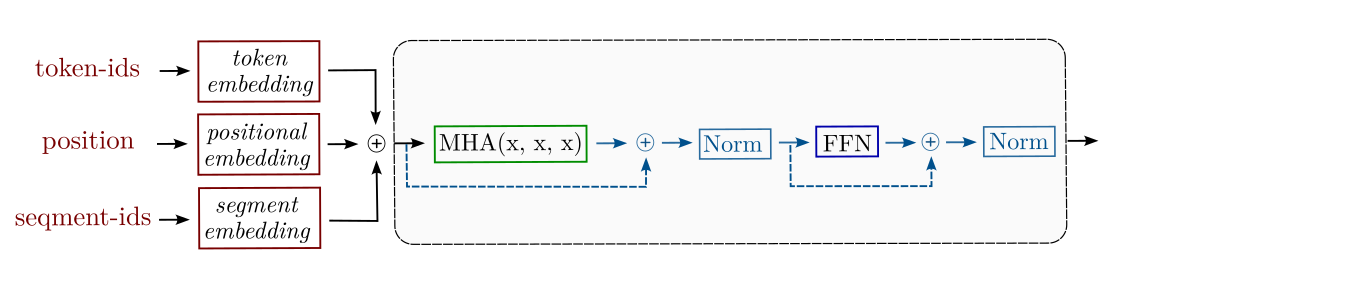</center></p><p style="text-align:center;"><em>A camada codificadora.</em>

In [5]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/IMD1107 - Processamento de Linguagem Natural/3-unidade/')

In [6]:
from myattention import MultiHeadAttention

In [7]:
class EncoderLayer(layers.Layer):

    def __init__(self, d_model, num_heads, dense_dim, rate=0.1):
        super().__init__()

        assert d_model % num_heads == 0

        self.mha = MultiHeadAttention(d_model, num_heads, dropout_rate=rate)

        self.ffn = Sequential([layers.Dense(dense_dim, activation='gelu'),
                               layers.Dense(d_model)])

        self.norm1 = layers.LayerNormalization(epsilon=1e-12)
        self.norm2 = layers.LayerNormalization(epsilon=1e-12)

        self.dropout = layers.Dropout(rate)

    def call(self, x, training, mask):

        x_attn = self.mha(x, x, x, mask=mask, training=training) # já temos dropout aqui
        x = self.norm1(x + x_attn)

        x_ffn = self.ffn(x)
        x_ffn = self.dropout(x_ffn, training=training)

        return self.norm2(x + x_ffn)


### **3.2 Implementando um "MiniBERT":**
<font size=3>

Agora, vamos empilhar as camadas de codificação, além de adicionar a saída **_pooler output_**: extraímos da última camada codificadora (vetor chamado **_sequence output_**) a vetorização do *token* `[CLS]` e o passamos por uma camada densa extra com função de ativação **tangente hiperbólica**. É esse vetor que geralmente usamos para tarefas de classificação.


<font size=3><center>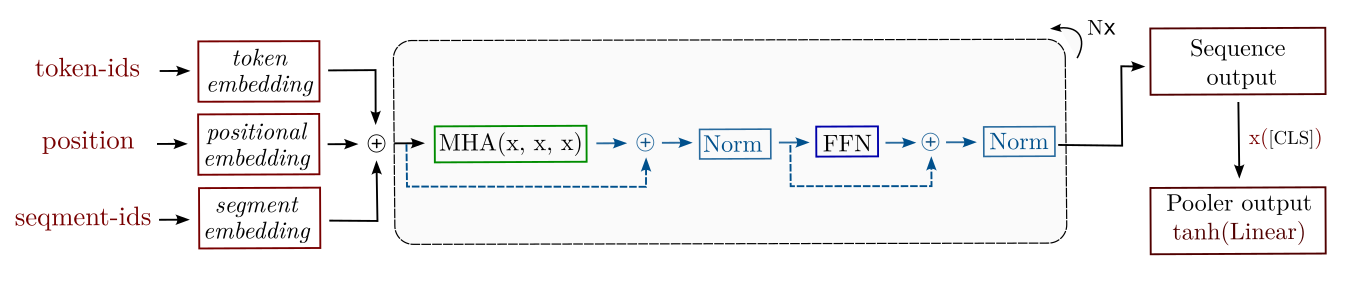</center></p><p style="text-align:center;"><em>Arquitetura do modelo BERT.</em>

In [8]:
from keras import Model

In [9]:
class MiniBERT(Model):

    def __init__(self, num_layers, d_model, num_heads, dense_dim, dropout_rate, vocab_size, max_len, seg_dim):
        super().__init__()

        self.d_model = d_model
        self.num_layers = num_layers

        self.embedding_layer = BertEmbeddings(vocab_size, max_len, d_model, seg_dim)

        self.encoder_layers = [EncoderLayer(d_model, num_heads, dense_dim, dropout_rate)
                               for _ in range(num_layers)]

        self.pooler_dense = layers.Dense(d_model, activation='tanh', name="pooler")


    def call(self, inputs, training=False):

        input_ids, segment_ids, mask = inputs

        #mask = mask[:, tf.newaxis, :] # (batch, 1, seq_len)

        x = self.embedding_layer((input_ids, segment_ids))

        for layer in self.encoder_layers:
            x = layer(x, training=training, mask=mask)

        # sequence output (x): (batch, seq_len, d_model) - representação de todos os tokens

        pooled_output = self.pooler_dense(x[:, 0, :]) # cls-token = x[:, 0, :] (batch, d_model)

        return x, pooled_output


### **3.3 Testando o fluxo de tensores:**
<font size=3>

Vamos instanciar nosso `MiniBERT` com configurações pequenas apenas para verificar se a matemática dimensional está funcionando.


In [10]:
import numpy as np

In [11]:
# configurações do modelo:
config = {"num_layers":3,
          "d_model":64,
          "num_heads":4,
          "dense_dim":128,
          "dropout_rate":0.1,
          "vocab_size":1000,
          "max_len":64,
          "seg_dim":1}

# definindo o modelo:
model = MiniBERT(**config)

# simulando os dados de entrada:
inp = tf.random.uniform((1, config["max_len"]), minval=0, maxval=100, dtype=tf.int32)
seg = tf.zeros((1, config["max_len"]), dtype=tf.int32)

mask = np.ones((1, config["max_len"]), dtype=np.int32)
mask[0, int(0.6*config["max_len"]):] = 0
mask = tf.constant(mask)

seq_out, pool_out = model((inp, seg, mask), training=False)

print(f"Entrada: {inp.shape}")
print(f"Saída Sequencial: {seq_out.shape}")
print(f"Saída Pooler: {pool_out.shape}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'bert_embeddings', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'encoder_layer' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'encoder_layer_1' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore de

Entrada: (1, 64)
Saída Sequencial: (1, 64, 64)
Saída Pooler: (1, 64)


## **4. O treinamento do _Masked Language Modeling_:**
<font size=3>

Até agora, construímos a estrutura que processa a informação. Mas como ensinamos esse modelo a "entender" a linguagem?

<font size=3>

Modelos autoregressivos (como o GPT) são treinados prevendo a próxima palavra: $P(x_t \mid x_{<t})$. Se tentássemos fazer isso em uma arquitetura bidirecional sem nenhuma restrição, a palavra na posição $t$ poderia simplesmente "olhar para si mesma" no futuro e a tarefa se tornaria trivial. A solução do BERT foi introduzir a **corrupção de texto**, transformando o treinamento em um processo de **_Denoising Autoencoder_**.

### **4.1 O paradigma da corrupção de texto:**
<font size=3>

*Masked Language Modeling* (MLM) consiste em esconder (mascarar) uma porcentagem dos *tokens* da entrada e pedir para que o modelo adivinhe quais eram esses *tokens* originais. Como o modelo não sabe qual *token* foi mascarado, ele é obrigado a usar todo o contexto ao redor (esquerda e direita) para fazer a predição.

Matematicamente, se $\tilde{x}$ é a nossa sequência corrompida e $\mathcal{M}$ é o conjunto de índices dos *tokens* que foram mascarados, nossa função de perda (*loss*) calculará o erro apenas sobre essas posições,
$$
    L_{MLM} = -\sum_{i \in \mathcal{M}} \log P(x_i \mid \tilde{x}) \, .
$$

Dessa forma, o modelo foca todo o seu poder computacional em reconstruir as lacunas, aprendendo relações semânticas e sintáticas profundas.

### **4.2 A estratégia dos 15%:**
<font size=3>

O artigo original do BERT propõe selecionar **15%** dos *tokens* de uma sequência para predição. No entanto, se simplesmente substituíssemos todos esses 15% pelo *token* especial `[MASK]`, criaríamos um problema grave: **descompasso entre treino e teste (*mismatch*)**. Na hora de fazer o *fine-tuning* para tarefas reais, o *token* `[MASK]` nunca apareceria, e o modelo ficaria confuso.

Para mitigar isso, **dentro dos 15%** selecionados, aplica-se a seguinte regra de corrupção:
1. **80% das vezes:** o *token* é substituído por `[MASK]`.
2. **10% das vezes:** o *token* é substituído por uma palavra aleatória do vocabulário. Isso força o modelo a não confiar cegamente na entrada e sempre checar o contexto.
3. **10% das vezes:** o *token* é mantido original. Isso ensina o modelo que a representação atual da palavra também é importante.

In [ ]:
def create_mlm_data(input_ids, vocab_size, mask_token_id, special_tokens_mask=None):

    """
    Aplica a estratégia dos 15% a um batch de input_ids.

    Args:
        input_ids: Tensor de entrada (batch_size, seq_len).
        vocab_size: Tamanho do vocabulário (para amostrar palavras aleatórias).
        mask_token_id: O ID correspondente ao token [MASK].
        special_tokens_mask: Máscara booleana para evitar mascarar [CLS], [SEP] e [PAD].
    """

    labels = tf.identity(input_ids)

    # criando uma matriz de probabilidades aleatórias do mesmo tamanho que input_ids:
    probability_matrix = tf.random.uniform(tf.shape(input_ids), minval=0.0, maxval=1.0)

    # Queremos corromper 15% dos tokens.
    # A máscara booleana será True onde a probabilidade for menor que 0.15:
    masked_indexes = probability_matrix < 0.15

    # ignora tokens especiais (como [PAD], [CLS], [SEP]) se a máscara for fornecida:
    if special_tokens_mask is not None:
        masked_indexes = tf.logical_and(masked_indexes, tf.logical_not(special_tokens_mask))

    # 80% dos 15% (ou seja, probabilidade < 0.8 do subset) viram [MASK].
    # Geramos novas probabilidades apenas para decidir o tipo de corrupção:
    corruption_probs = tf.random.uniform(tf.shape(input_ids), minval=0.0, maxval=1.0)

    indices_replaced = tf.logical_and(masked_indexes, corruption_probs < 0.8)
    input_ids = tf.where(indices_replaced, tf.fill(tf.shape(input_ids), mask_token_id), input_ids)

    # 10% dos 15% (probabilidade entre 0.8 e 0.9) viram palavras aleatórias:
    indices_random = tf.logical_and(masked_indexes, tf.logical_and(corruption_probs >= 0.8, corruption_probs < 0.9))
    random_words = tf.random.uniform(tf.shape(input_ids), minval=0, maxval=vocab_size, dtype=tf.int32)
    input_ids = tf.where(indices_random, random_words, input_ids)

    # Os 10% restantes (probabilidade >= 0.9) permanecem originais.
    # O código já faz isso naturalmente ao não alterar o input_ids nessas posições.

    # Ajustando os labels: os tokens que NÃO foram selecionados para a máscara
    # recebem o valor -100 para serem ignorados no cálculo da função de perda (loss).
    labels = tf.where(masked_indexes, labels, tf.fill(tf.shape(labels), -100))

    return input_ids, labels



In [ ]:
# simulando um batch de 1 frase com 10 tokens:
ex_inputs = tf.constant([[101, 2050, 3100, 4000, 5021, 6012, 7033, 8044, 9055, 102]])

# simulando máscara de tokens especiais (True para as pontas):
ex_special = tf.constant([[True, False, False, False, False, False, False, False, False, True]])

masked_inputs, masked_labels = create_mlm_data(input_ids=ex_inputs,
                                               vocab_size=10000,
                                               mask_token_id=99, # supondo que 99 seja o ID do [MASK]
                                               special_tokens_mask=ex_special
                                              )

print(f"Original: {ex_inputs.numpy()[0]}")
print(f"Corrompido: {masked_inputs.numpy()[0]}")
print(f"Labels:   {masked_labels.numpy()[0]}")

### **4.3 Preparando o *corpus*:**
<font size=3>

O BERT original foi submetido a um pré-treinamento massivo utilizando o *BooksCorpus* (800 milhões de palavras) e a *English Wikipedia* (2.5 bilhões de palavras). Para viabilizar a execução em sala de aula e poupar recursos computacionais, utilizaremos um recorte estratégico de **1% da Wikipédia em inglês**.

<font size=3>

Agora, precisamos acatar um detalhe técnico: embora o Keras ofereça a camada `TextVectorization`, modelos como o BERT exigem uma estratégia mais sofisticada, a **Tokenização de Subpalavras (_Subword Tokenization_)** via algoritmo [_WordPiece_](https://huggingface.co/learn/llm-course/en/chapter6/6):   
>A tokenização tradicional por palavras inteiras enfrenta dois grandes problemas: o tamanho explosivo do vocabulário e a incapacidade de lidar com palavras desconhecidas (*Out-of-Vocabulary* — OOV). O *WordPiece* resolve isso decompondo palavras complexas em unidades estatisticamente significantes.
>
>1. **Decomposição semântica:** Palavras são fragmentadas em prefixos e sufixos. Por exemplo, a palavra `"inconstitucionalmente"` pode ser tokenizada como `["in", "##constitucional", "##mente"]`.
>2. **O marcador `##`:** O prefixo `##` é uma convenção que indica que aquele *token* é a continuação de uma palavra anterior, e não o início de uma nova. Isso permite que o modelo preserve a estrutura morfológica da palavra enquanto mantém um vocabulário fixo e compacto (geralmente em torno de 30.000 tokens).
>3. **Robustez ao OOV:** Se o modelo encontra uma palavra nunca vista no treinamento, ele tenta reconstruí-la através de suas subunidades. No limite, ele pode decompor uma palavra até o nível de caracteres individuais, garantindo que o modelo nunca fique "sem resposta" perante um termo novo.

Nesta aula, utilizaremos o [`BertTokenizerFast`](https://huggingface.co/docs/transformers/en/main_classes/tokenizer) da biblioteca **Hugging Face**, carregando o vocabulário do modelo `bert-base-cased`. Optamos pela versão *Fast* (implementada em Rust) para garantir máxima velocidade no processamento do *pipeline* de dados. Como nosso objetivo final é classificar o dataset **IMDB** (em inglês), é imperativo que o nosso pré-treino também ocorra em inglês para garantir o alinhamento do espaço vetorial.

<font size=3>

Nesta etapa, iremos:
1. **Ingestão de dados:** Baixar o *subset* da Wikipédia em inglês.

2. **Tokenização eficiente:** Mapear o algoritmo *WordPiece* sobre o *corpus*, gerando não apenas os `input_ids`, mas também as máscaras de atenção e os *segment IDs*.

3. **Pipeline de dados:** Estruturar um objeto `tf.data.Dataset` que realize a corrupção MLM (máscaras de 15%) em tempo real durante o treinamento.

In [ ]:
from datasets import load_dataset
from transformers import BertTokenizerFast

In [ ]:
# carregando os dados brutos:
dset_raw = load_dataset("wikimedia/wikipedia", "20231101.en", split="train[:10_000]")

# dividindo em treino e validação:
dset_split = dset_raw.train_test_split(test_size=0.1, seed=42)
train_raw = dset_split["train"]
val_raw = dset_split["test"]

print(f"Artigos de Treino: {len(train_raw)}")
print(f"Artigos de Validação: {len(val_raw)}")

<font size=3>
    
Agora, vamos aplicar a tokenização em lote. A biblioteca nos permite retornar não apenas os `input_ids`, mas também a máscara de *tokens* especiais (`special_tokens_mask`), que usaremos para garantir que *tokens* cruciais como `[CLS]`, `[SEP]` e o preenchimento `[PAD]` **não sejam corrompidos** pelo MLM.

In [ ]:
# configurações da tokenização:
tokenizer = BertTokenizerFast.from_pretrained("bert-base-cased")
config['vocab_size'] = tokenizer.vocab_size
batch_size = 64

print("vocab-size:", config['vocab_size'])

def tokenize_fun(samples):
    return tokenizer(samples["text"],
                     padding="max_length",
                     truncation=True,
                     max_length=config['max_len'],
                     return_special_tokens_mask=True)

# aplicando a tokenização em ambos os splits:
train_tokenized = train_raw.map(tokenize_fun, batched=True, remove_columns=train_raw.column_names)
val_tokenized = val_raw.map(tokenize_fun, batched=True, remove_columns=val_raw.column_names)

# exportando para TF Dataset:
train_tf = train_tokenized.to_tf_dataset(columns=["input_ids", "token_type_ids", "attention_mask", "special_tokens_mask"],
                                         shuffle=True, batch_size=batch_size)

val_tf = val_tokenized.to_tf_dataset(columns=["input_ids", "token_type_ids", "attention_mask", "special_tokens_mask"],
                                     shuffle=False, batch_size=batch_size)


In [ ]:
# função de aplicação do MLM:
def apply_mlm(batch_dict):

    input_ids = tf.cast(batch_dict["input_ids"], tf.int32)
    segment_ids = tf.cast(batch_dict["token_type_ids"], tf.int32)
    pad_mask = tf.cast(batch_dict["attention_mask"], tf.int32)
    special_tokens_mask = tf.cast(batch_dict["special_tokens_mask"], tf.bool)

    masked_inputs, labels = create_mlm_data(input_ids=input_ids,
                                            vocab_size=config['vocab_size'],
                                            mask_token_id=tokenizer.mask_token_id,
                                            special_tokens_mask=special_tokens_mask)

    return (masked_inputs, segment_ids, pad_mask), labels

# pipelines finais mapeados:
train_dset = train_tf.map(apply_mlm, num_parallel_calls=tf.data.AUTOTUNE)
val_dset = val_tf.map(apply_mlm, num_parallel_calls=tf.data.AUTOTUNE)

print(f"Steps por época (treino): {len(train_dset)}")
print(f"Steps por época (validação): {len(val_dset)}")

In [ ]:
# deletando objetos não mais nescessários:
del dset_split, train_raw, val_raw
del train_tokenized, val_tokenized
del train_tf, val_tf

### **4.4 MLM Head:**
<font size=3>
    
Até o momento, o nosso `MiniBERT` (construído na Seção 3) atua puramente como um extrator de características. Quando passamos uma frase por ele, obtemos duas saídas:
1. `seq_out`: Os vetores contextualizados para cada *token* da sequência.
2. `pool_out`: O vetor agregado do *token* `[CLS]`.

Para a tarefa de *Masked Language Modeling* (MLM), nós ignoramos o `pool_out` e focamos apenas no `seq_out`. O objetivo é pegar o vetor de saída na posição exata onde inserimos um `[MASK]` e descobrir qual era a palavra original.

<font size=3>

Nesta implementação, utilizaremos uma técnica de otimização chamada **_Weight Tying_**. Em vez de criarmos uma nova matriz de pesos aleatórios para projetar a saída de volta ao tamanho do vocabulário, **reutilizamos a própria matriz da camada de Embedding**.
> Se a matriz de embedding aprendeu a transformar um ID de palavra em um vetor semântico, a sua transposta é a ferramenta ideal para transformar esse vetor semântico de volta no ID da palavra original. Isso reduz drasticamente o número de parâmetros e força o modelo a aprender representações mais robustas.

Matematicamente, aplicamos primeiro uma cabeça de transformação (camada Densa com ativação GELU e LayerNorm) e, em seguida, realizamos o produto escalar com a transposta da matriz de embeddings $\left(W_{emb}^T\right)$,
$$
    \text{logits} = \text{LayerNorm}\left(\text{GELU}(x \cdot W_1 + b_1)\right) \cdot W_{emb}^T + b_{out}\, ,
$$
onde:
* $x$ é a saída sequencial do *Encoder* (`seq_out`).
* $W_1$ e $b_1$ são os pesos da camada densa de transformação.
* $W_{emb}$ são os pesos compartilhados da camada de **_token embedding_**.
* $b_{out}$ é um vetor de *bias* treinado especificamente para a saída, que ajuda o modelo a capturar a frequência natural (popularidade) das palavras no idioma.

In [ ]:
class MLMHead(layers.Layer):

    def __init__(self, vocab_size, d_model, embedding_layer):
        super().__init__(name="mlm_head")

        self.embedding_layer = embedding_layer

        self.dense = layers.Dense(d_model, activation='gelu', name="mlm_dense")

        self.norm = layers.LayerNormalization(epsilon=1e-12)

        self.bias = self.add_weight(shape=(vocab_size,), initializer="zeros",
                                    trainable=True, name="output_bias")

    def call(self, x):

        x = self.dense(x)
        x = self.norm(x)

        # weight tying - reutiliza os pesos da matriz de embeddings:
        weights = self.embedding_layer.token_emb.embeddings

        return tf.matmul(x, weights, transpose_b=True) + self.bias


class MLMBert(Model):

    def __init__(self, config):
        super().__init__(name="mlm_bert")

        self.bert = MiniBERT(**config)

        self.mlm_head = MLMHead(config['vocab_size'], config['d_model'],
                                embedding_layer=self.bert.embedding_layer)

    def call(self, inputs, training=False):

        seq_out, pool_out = self.bert(inputs, training=training)

        return self.mlm_head(seq_out)


In [ ]:
# criando o modelo de pré-treino:
mlm_model = MLMBert(config)

# testendo 1 batch do dataset:
for batch_inputs, batch_labels in train_dset.take(1):
    batch_logits = mlm_model(batch_inputs, training=False)

    print(f"Shape de entrada (input IDs): {batch_inputs[0].shape}")
    print(f"Shape da saída (logits):      {batch_logits.shape}")


### **4.5 O pré-treinamento:**
<font size=3>
    
Agora que temos o nosso `MiniBERT` corrompendo frases e tentando adivinhar as palavras ocultas através do *MLM Head*, precisamos ensiná-lo com base nos seus erros.

A sacada do pré-treinamento do BERT está na forma como calculamos o erro (*Loss*). Diferente de tarefas comuns, onde avaliamos a saída inteira, **o BERT só é avaliado naqueles 15% de tokens que nós mascaramos**. Se ele acertar ou errar as palavras que nós *não* escondemos, não nos importamos.

> Vamos criar uma função que calcula a **entropia cruzada**, mas que aplica um "filtro" para somar apenas os erros das posições mascaradas.

In [ ]:
import time
import matplotlib.pyplot as plt
from keras import optimizers

In [ ]:
def loss_fun(y_true, y_pred, masked_indexes):

    """
    Calcula o erro de predição apenas para os tokens corrompidos.

    y_true: IDs reais do vocabulário (Batch, Seq_Len)
    y_pred: Logits (chutes) gerados pelo modelo (Batch, Seq_Len, Vocab_Size)
    masked_indexes: Tensor booleano indicando onde a máscara foi aplicada (Batch, Seq_Len)
    """

    # calculando o erro para todos os tokens da sequência:
    loss_fun = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')
    loss_total = loss_fun(y_true, y_pred)

    # convertendo os booleanos (True/False) para números (1.0 / 0.0):
    mask_weights = tf.cast(masked_indexes, dtype=loss_total.dtype)

    # zerando o erro onde não havia máscara (multiplicando por 0.0):
    loss_filtered = loss_total*mask_weights

    # retorna a média do erro dividindo apenas pela quantidade de tokens avaliados:
    error_sum = tf.reduce_sum(loss_filtered)
    n_masks = tf.reduce_sum(mask_weights)

    # evitando divisão por zero caso nenhum token tenha sido mascarado no lote:
    return error_sum/(n_masks + 1e-9)


<font size=3>

Como a entropia cruzada não retorna valores palatáveis para nossa interpretação de desempenho, vamos considerar a métrica **acurácia** adaptada para acompanhar o treinamento do modelo.

In [ ]:
def acc_fun(y_true, y_pred, masked_indexes):

    """
    Calcula a taxa de acerto do modelo apenas para os tokens que foram mascarados.

    y_true: IDs reais do vocabulário (Batch, Seq_Len)
    y_pred: Logits gerados pelo modelo (Batch, Seq_Len, Vocab_Size)
    masked_indexes: Tensor booleano indicando onde a máscara foi aplicada
    """

    # obtendo a classe (ID do vocabulário) com maior probabilidade:
    pred_ids = tf.argmax(y_pred, axis=-1, output_type=y_true.dtype)

    # verificando quais predições bateram com o gabarito original:
    correct_predictions = tf.equal(y_true, pred_ids)

    # convertendo os booleanos para float para a matemática:
    correct_predictions = tf.cast(correct_predictions, tf.float32)
    mask_weights = tf.cast(masked_indexes, tf.float32)

    # zerando os acertos que ocorreram fora das posições mascaradas
    # (Não queremos inflar a acurácia com palavras que o modelo já estava vendo):
    correct_masked = correct_predictions*mask_weights

    # somando os acertos válidos e as máscaras aplicadas no lote:
    total_correct = tf.reduce_sum(correct_masked)
    total_masks = tf.reduce_sum(mask_weights)

    # retornando a porcentagem de acerto (evitando divisão por zero):
    return total_correct/(total_masks + 1e-9)


<font size=3>

Treinar um modelo da família *Transformer* do zero é uma tarefa extremamente delicada. Se utilizarmos uma taxa de aprendizado (*learning rate*) fixa e alta desde o primeiro passo, o modelo pode divergir imediatamente, "destruindo" os pesos e estagnando o aprendizado em uma *loss* muito alta.

> Embora o otimizador **Adam** seja adaptativo — ajustando a intensidade da atualização para cada parâmetro isoladamente — ele não possui a percepção "macro" de em qual fase do treinamento nós estamos.

Para contornar essa instabilidade, iremos acoplar ao otimizador um **agendador de taxa de aprendizado** dividido em duas fases dinâmicas:
1. **Warmup (aquecimento):** Nos primeiros passos do treinamento (geralmente os primeiros 10%), a taxa de aprendizado global começa em zero e **sobe linearmente** até o valor máximo desejado (como 1e-4). Isso permite que os pesos se "acomodem" suavemente, estabilizando os gradientes.

2. **Linear Decay (decaimento):** Após atingir o pico de aprendizado, a taxa **cai linearmente** até chegar a zero no final das épocas. Isso funciona como um motorista tirando o pé do acelerador: os passos do modelo ficam cada vez menores e mais precisos, o que é fundamental para estacionar exatamente no mínimo global da função de custo.


In [ ]:
class WarmupLinearSchedule(optimizers.schedules.LearningRateSchedule):

    def __init__(self, base_lr, total_steps, warmup_steps):
        super().__init__()

        self.base_lr = base_lr
        self.total_steps = tf.cast(total_steps, tf.float32)
        self.warmup_steps = tf.cast(warmup_steps, tf.float32)

    def __call__(self, step):

        step = tf.cast(step, tf.float32)

        # warmup (aumento linear):
        warmup_lr = self.base_lr*(step/self.warmup_steps)

        # linear decay (diminuição linear após o warmup):
        decay_steps = self.total_steps - self.warmup_steps
        step_after_warmup = step - self.warmup_steps

        # garantindo que o decaimento não fique negativo (minimo 0):
        decay_lr = self.base_lr*tf.maximum(0.0, (decay_steps - step_after_warmup)/decay_steps)

        # retorna warmup_lr se step < warmup_steps, caso contrário retorna decay_lr:
        return tf.where(step < self.warmup_steps, warmup_lr, decay_lr)


<font size=3>
    
Finalmente, iremos implementar o **_loop_ de treinamento**, onde o `MLMBert` irá aprender o contexto linguístico dos artigos da Wikipédia.

In [ ]:
%%time
n_epochs = 3

history = {"loss":[], "accuracy":[],
           "val_loss":[], "val_accuracy":[]}

n_train_steps = len(train_dset)

# definindo o otimizador com agendador de taxa de aprendizagem:
lr_schedule = WarmupLinearSchedule(1e-4, n_train_steps, int(n_train_steps*0.1))
optimizer = optimizers.Adam(learning_rate=lr_schedule)


for epoch in range(1, n_epochs+1):
    start_time = time.time()

    print(f"#Epoch {epoch}/{n_epochs}:")

    # métricas auxiliares para treino:
    loss_avg = tf.keras.metrics.Mean()
    acc_avg = tf.keras.metrics.Mean()

    # fase de treino:
    for step, (batch_x, batch_labels) in enumerate(train_dset, start=1):

        masked_indexes = (batch_labels != -100)
        batch_labels = tf.maximum(batch_labels, 0)

        with tf.GradientTape() as tape:
            logits_predicao = mlm_model(batch_x, training=True)

            loss_value = loss_fun(batch_labels, logits_predicao, masked_indexes)

        gradients = tape.gradient(loss_value, mlm_model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, mlm_model.trainable_variables))

        acc_value = acc_fun(batch_labels, logits_predicao, masked_indexes)

        loss_avg.update_state(loss_value)
        acc_avg.update_state(acc_value)

        print(f"Batch:{int(100*step/n_train_steps)}%", end=' - ')
        print(f"Accuracy = {acc_value:.2f}", end='\r', flush=True)

    print()

    # métricas auxiliares para validação:
    val_loss_avg = tf.keras.metrics.Mean()
    val_acc_avg = tf.keras.metrics.Mean()

    # fase de validação:
    for batch_x_val, batch_labels_val in val_dset:

        masked_indexes_val = (batch_labels_val != -100)
        batch_labels_val = tf.maximum(batch_labels_val, 0)

        logits_val = mlm_model(batch_x_val, training=False)

        val_loss = loss_fun(batch_labels_val, logits_val, masked_indexes_val)
        val_acc = acc_fun(batch_labels_val, logits_val, masked_indexes_val)

        val_loss_avg.update_state(val_loss)
        val_acc_avg.update_state(val_acc)

    print(f"Validation: Acc = {val_acc:.2f}")
    print(f"Time taken: {time.time() - start_time:.2f}s\n")

    # armazenando resultados:
    history["loss"].append(loss_avg.result().numpy())
    history["accuracy"].append(acc_avg.result().numpy())
    history["val_loss"].append(val_loss_avg.result().numpy())
    history["val_accuracy"].append(val_acc_avg.result().numpy())


In [ ]:
epochs = range(1, n_epochs+1)

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, history['loss'], label='Treino')
plt.plot(epochs, history['val_loss'], label='Validação', ls='--')
plt.ylabel('Loss', fontsize=12)
plt.xlabel('Épocas', fontsize=12)
plt.legend(fontsize=12)
plt.grid(ls='--')

plt.subplot(1, 2, 2)
plt.plot(epochs, history['accuracy'], label='Treino')
plt.plot(epochs, history['val_accuracy'], label='Validação', ls='--')
plt.ylabel('Acurácia', fontsize=12)
plt.xlabel('Épocas', fontsize=12)
plt.legend(fontsize=12)
plt.grid(ls='--')

plt.show()

### **4.6 Salvando o modelo pré-treinado:**
<font size=3>
    
Após um longo tempo de processamento, o modelo desenvolveu uma compreensão interna da língua inglesa. Vamos salvar esses pesos. Utilizaremos o formato `.weights.h5`, que é eficiente e evita problemas de serialização com camadas customizadas no Keras.

In [ ]:
# salvando os pesos do MiniBERT + MLM Head:
mlm_model.save_weights('/content/drive/MyDrive/IMD1107 - Processamento de Linguagem Natural/3-unidade/weights/mlmbert.weights.h5')

# salvando apenas o MiniBert:
mlm_model.bert.save_weights('/content/drive/MyDrive/IMD1107 - Processamento de Linguagem Natural/3-unidade/weights/minibert.weights.h5')

<font size=3>
<br>
    
Para que o modelo seja carregado posteriormente, precisamos também salvar o **dicionário de configuração** (`config`) que apresenta os hiperparâmetros da estrutura da arquitetura.

In [ ]:
import json

In [ ]:
# salvando o dicionário em um arquivo json:
with open('/content/drive/MyDrive/IMD1107 - Processamento de Linguagem Natural/3-unidade/weights/minibert_config.json', 'w') as f:
    json.dump(config, f, indent=4)

config

<font size=3>
<br>
    
Agora, com o `MiniBERT` pré-treinado com o **conhecimento linguístico** da Wikipédia, iremos, no próximo *notebook*, carregá-lo e torná-lo um **especialista** nos dados do IMDB para classificação de análise de sentimentos de filmes.
